## Change of variable

Suppose we have a posterior distribution of $\theta_1,\ \theta_2$ given by
$$
p(\theta_1, \theta_2 \mid d) 
$$
and we would like to transform it into the distribution of $\vartheta_1,\ \vartheta_2$, then by the change of variable formula, it amounts to:
$$
p(\vartheta_1, \vartheta_2 \mid d) = 
\vert J \vert \,
p(\theta_1, \theta_2 \mid d)
$$
where $\vert J \vert $ is the Jacobian:
$$
\vert J \vert = 
\begin{vmatrix}
\frac{\partial \theta_1}{\partial \vartheta_1} & \frac{\partial \theta_2}{\partial \vartheta_1} \\
\frac{\partial \theta_1}{\partial \vartheta_2} & \frac{\partial \theta_2}{\partial \vartheta_2} \\
\end{vmatrix}
$$

In [2]:
import jax
jax.config.update("jax_enable_x64", True)
from jax.lax import integer_pow
from gwfast.gwfastGlobals import DAY_TO_SEC
from gwfast.lensing_utils import compute_lensed_angles_approx

from pathlib import Path
from jax import config
import jax.numpy as np
import numpy as onp
from jax.lax import broadcast_in_dim
config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MTSUN_SI, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
import gwfast.network as network
from gwfast.signals import AGNLensedGWSignal, GeneralLensedGWSignal
from gwfast.fisherTools import (
    reduce_Fisher_matrix, 
    plot_corners, compute_covariance_matrix, 
    print_matrices, covariance_change_variable
)


/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [3]:
def lensing_transform(lensing_parameters):
    # A fiducial phase which does not affect the Jacobian results
    lensing_parameters['phase'] = 0.0
    outputs = compute_lensed_angles_approx(lensing_parameters)
    phenom_changes = {}
    phenom_changes['delta_iota'] = outputs['iota_m'] - outputs['iota_p']
    phenom_changes['delta_phi'] = outputs['phase_m'] - outputs['phase_p']

    # (Radial gravitational potential is cancelled)
    phenom_changes['relative_mass'] = (1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p'])
    relative_magification = outputs['sqrt_mu_p'] / outputs['sqrt_mu_m']
    phenom_changes['relative_distance'] = relative_magification * integer_pow((1 + outputs['z_rel_m']) / (1 + outputs['z_rel_p']), 2)
    phenom_changes['delta_time'] = outputs['delta_time']
    return phenom_changes


def m1m2_from_Mceta(Mc, eta):
    """
    Compute the component masses of a binary given its chirp mass and symmetric mass ratio.

    :param array or float Mc: Chirp mass of the binary, :math:`{\cal M}_c`.
    :param array or float eta: The symmetric mass ratio(s), :math:`\eta`, of the objects.
    :return: :math:`m_1` and :math:`m_2`.
    :rtype: tuple(array, array) or tuple(float, float)

    """
    delta = 1 - 4 * eta
    return (1 + np.sqrt(delta)) / 2 * Mc / eta ** (3.0 / 5.0), (
        1 - np.sqrt(delta)
    ) / 2 * Mc / eta ** (3.0 / 5.0)

In [28]:
J1 = jax.jacfwd(lensing_transform)({
    'iota': np.pi/2 * 0.97, 'phase': 0.4, 'R_orbit': 300., 'src_pos': 0.1, 
    'M_lz': 1e6, 'dL': 1.
})

J2 = jax.jacfwd(lensing_transform)({
    'iota': np.pi/2 * 0.97, 'phase': 0.0, 'R_orbit': 300., 'src_pos': 0.1, 
    'M_lz': 1e6, 'dL': 1.
})

J1_arr = np.array(jax.tree.leaves(J1))
J2_arr = np.array(jax.tree.leaves(J2))
J1_arr - J2_arr

Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64)

## Actually test it on a Fisher matrix

In [4]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

In [5]:
shape = 3
lensing_parameters = {
    'Mc': 80, 'eta': 0.23, 'iota': 0.99 * np.pi / 2, 'phase': 2.1,
    'chi1z': 0.3, 'chi2z': 0.4, 'tcoal': 0.0,
    'theta': 0.1, 'phi': 0.3, 'psi': 0.3, 'dL': 2.0, 
    'R_orbit': 100, 'M_lz': 5e5, 'src_pos': 0.2
}
lensing_parameters = {key: np.full(shape, val).astype(np.float64) for key, val in lensing_parameters.items()}
lensing_parameters['src_pos'] = - np.arange(1, 6, 2) * 0.05

HLV_fisher = HLV_AGN.FisherMatr(lensing_parameters, res=1000)

trans_lensing_parameters = lensing_parameters.copy()
Mc = trans_lensing_parameters.pop('Mc')
eta = trans_lensing_parameters.pop('eta')

m1, m2 = m1m2_from_Mceta(Mc, eta)
trans_lensing_parameters['m1'] = m1
trans_lensing_parameters['m2'] = m2
trans_lensing_parameters = {
    key: np.full(shape, val).astype(np.float64) for key, val in trans_lensing_parameters.items()
}

direct_HLV_fisher = HLV_AGN.FisherMatr(trans_lensing_parameters, res=1000)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 17.65215266133077, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 30.640940863459154, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.75541455272001.

Warning! Some of the input parameters will likely yield waveforms with signal length longer th

In [6]:
keys = list(lensing_parameters.keys()).copy()
reduce_fisher_mat, _ = reduce_Fisher_matrix(HLV_fisher, keys=keys)
# Convert to regular numpy for float128 support
reduce_fisher_mat = onp.array(reduce_fisher_mat)
reduced_cov_mats, ie = compute_covariance_matrix(reduce_fisher_mat)

# dt_idx = keys.index('delta_time')
# # Convert delta_time from days to seconds
# reduced_cov_mats[dt_idx, :, :] *= DAY_TO_SEC
# reduced_cov_mats[:, dt_idx, :] *= DAY_TO_SEC

labels = {
    'm1': r'$m_1\,/\,M_\odot$',
    'm2': r'$m_2\,/\,M_\odot$',
    'mass_1': r'$m_1\,/\,M_\odot$',
    'mass_2': r'$m_2\,/\,M_\odot$',
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'phase': r'$\phi\,/\,{\rm rad}$',
    'chi1z': r'$\chi_{1z}$',
    'chi2z': r'$\chi_{2z}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lz': r'$M_{\rm Lz}\,/\,M_\odot$',
    'src_pos': r'$y$',
    'delta_iota': r'$\Delta \iota\,/\,{\rm rad}$',
    'delta_phase': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_phi': r'$\Delta \phi\,/\,{\rm rad}$',
    'delta_time': r'$\Delta t\,/\,{\rm s}$',
    'relative_mass': r'${\cal M}_2 \,/\,{\cal M}_1$',
    'relative_distance': r'$D_{L,2} \,/\,D_{L,1}$',
}

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


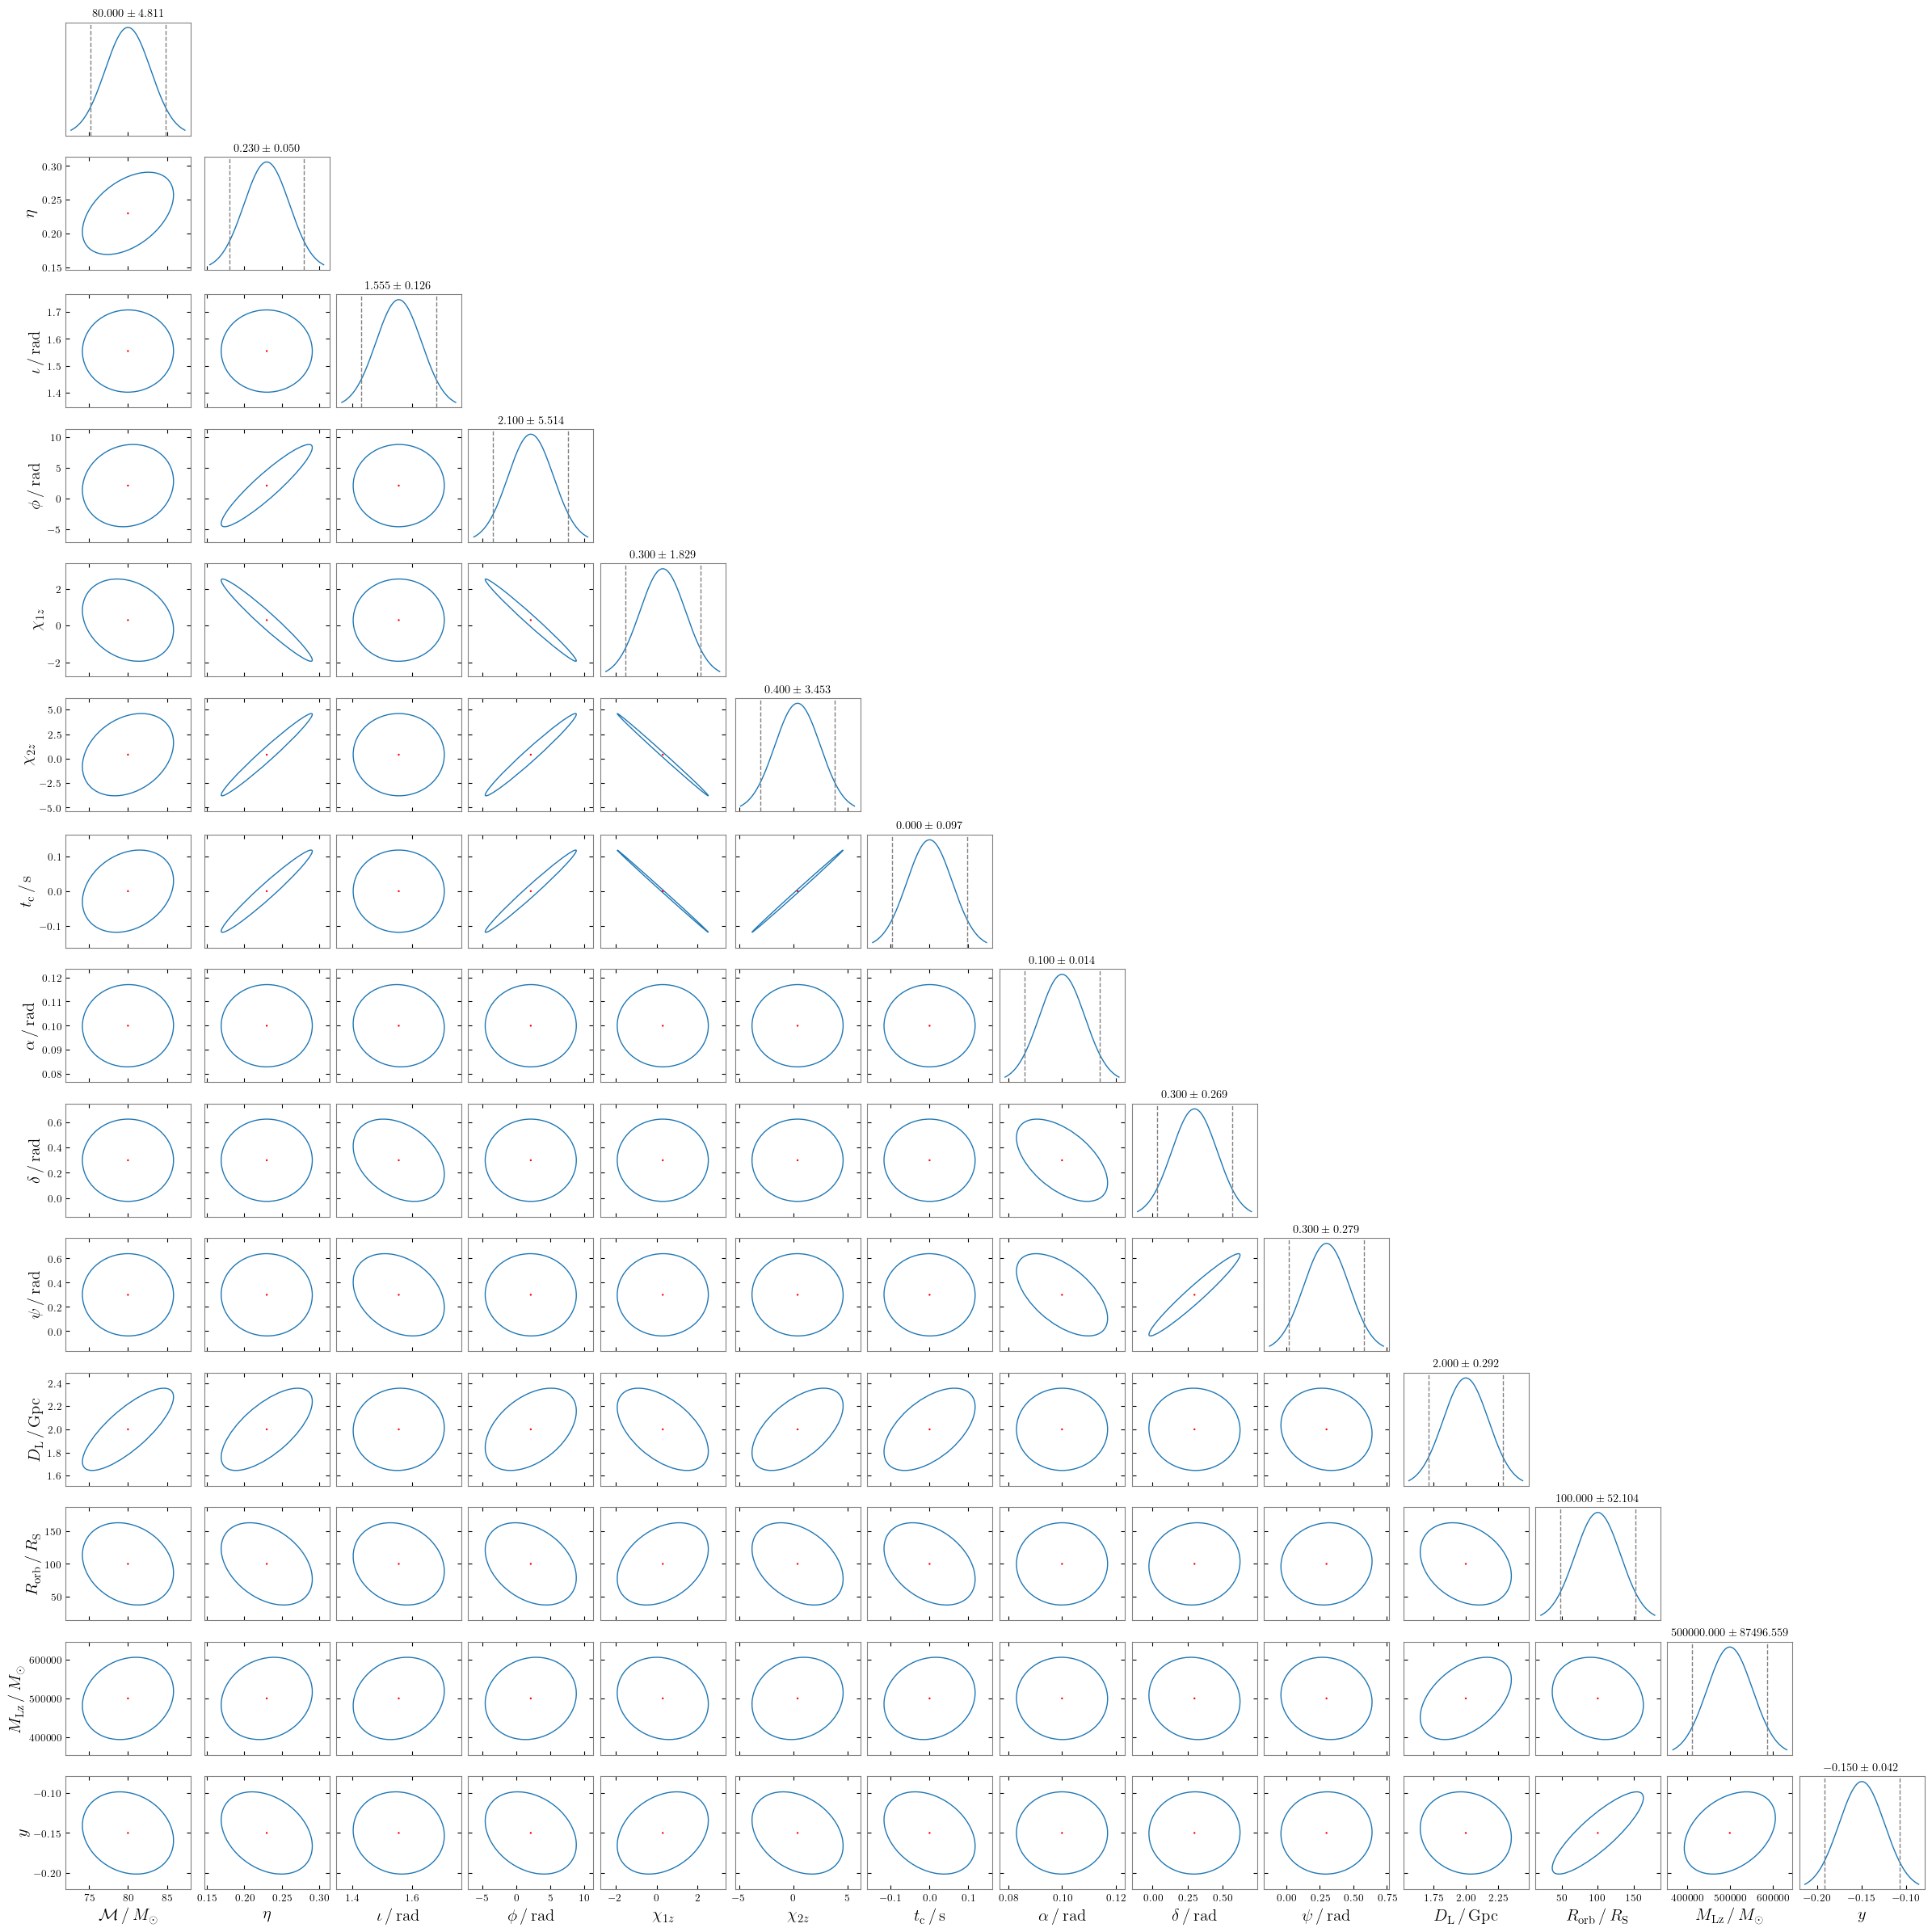

In [7]:
idx = 1
indices = np.arange(0, len(keys))
parameters = {key: val[idx] for key, val in lensing_parameters.items()}
# parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    reduced_cov_mats[:, :, idx], keys, indices, 
    event=parameters, labels=labels, color='C0'
)

In [8]:
sub_lensing_parameters = {key: lensing_parameters[key] for 
                          key in ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']}
jax.vmap(jax.jacfwd(lensing_transform))(sub_lensing_parameters)

{'delta_iota': {'M_lz': Array([-5.50796102e-23, -5.45246378e-23, -5.33973918e-23], dtype=float64),
  'R_orbit': Array([4.43769085e-04, 1.46432582e-04, 8.60431350e-05], dtype=float64),
  'dL': Array([1.69091723e-17, 1.67387985e-17, 1.63927395e-17], dtype=float64),
  'iota': Array([5.65117301, 1.86474426, 1.09571545], dtype=float64),
  'src_pos': Array([-1.77952515, -0.19973754, -0.07342348], dtype=float64)},
 'delta_phi': {'M_lz': Array([1.66683867e-22, 5.23821099e-22, 8.76127051e-22], dtype=float64),
  'R_orbit': Array([-0.00134295, -0.00140679, -0.00141177], dtype=float64),
  'dL': Array([-5.11711363e-17, -1.60810529e-16, -2.68966742e-16], dtype=float64),
  'iota': Array([1.86363521, 0.18972957, 0.06236158], dtype=float64),
  'src_pos': Array([-0.58817774, -0.02079585, -0.00447605], dtype=float64)},
 'delta_time': {'M_lz': Array([1.02795442e-05, 3.22402625e-05, 5.82474219e-05], dtype=float64),
  'R_orbit': Array([0.02596305, 0.087367  , 0.17451569], dtype=float64),
  'dL': Array([-0.5

In [9]:
reduce_fisher_mat.shape, keys

((14, 14, 3),
 ['Mc',
  'eta',
  'iota',
  'phase',
  'chi1z',
  'chi2z',
  'tcoal',
  'theta',
  'phi',
  'psi',
  'dL',
  'R_orbit',
  'M_lz',
  'src_pos'])

In [10]:
lensing_parameters

{'Mc': Array([80., 80., 80.], dtype=float64),
 'eta': Array([0.23, 0.23, 0.23], dtype=float64),
 'iota': Array([1.55508836, 1.55508836, 1.55508836], dtype=float64),
 'phase': Array([2.1, 2.1, 2.1], dtype=float64),
 'chi1z': Array([0.3, 0.3, 0.3], dtype=float64),
 'chi2z': Array([0.4, 0.4, 0.4], dtype=float64),
 'tcoal': Array([0., 0., 0.], dtype=float64),
 'theta': Array([0.1, 0.1, 0.1], dtype=float64),
 'phi': Array([0.3, 0.3, 0.3], dtype=float64),
 'psi': Array([0.3, 0.3, 0.3], dtype=float64),
 'dL': Array([2., 2., 2.], dtype=float64),
 'R_orbit': Array([100., 100., 100.], dtype=float64),
 'M_lz': Array([500000., 500000., 500000.], dtype=float64),
 'src_pos': Array([-0.05, -0.15, -0.25], dtype=float64, weak_type=True)}

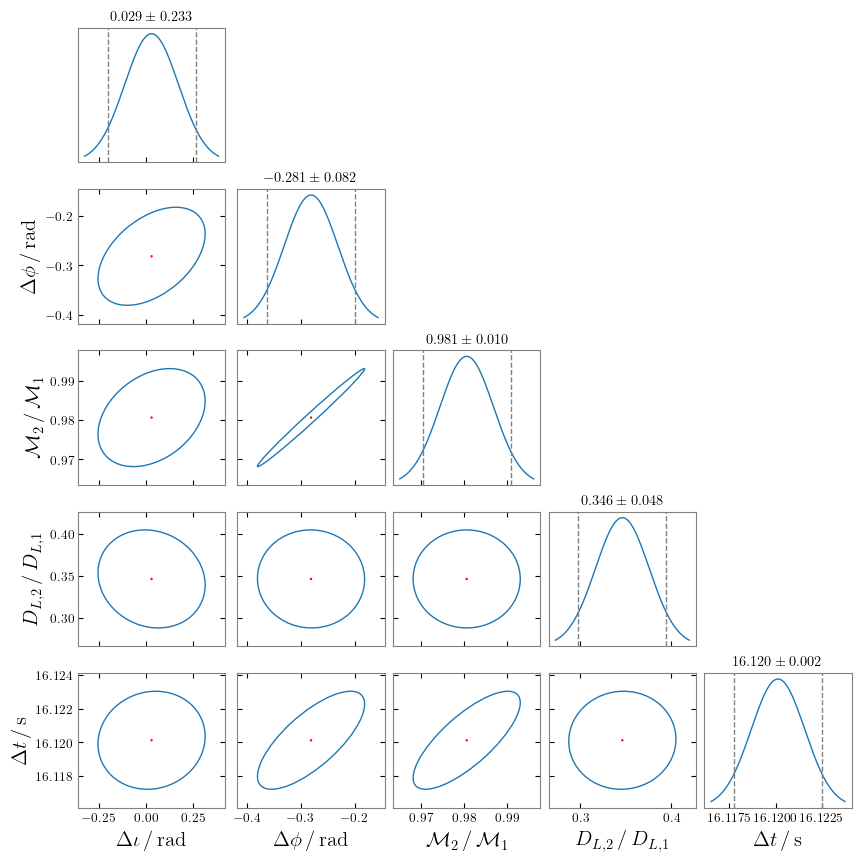

In [29]:
from_params = ['iota', 'R_orbit', 'src_pos', 'M_lz', 'dL']
transformed_cov_mat, transformed_parameters, transformed_keys = covariance_change_variable(
    reduced_cov_mats, lensing_parameters, lensing_transform, from_params
)

idx = 1
original_keys = list(lensing_parameters.keys())
indices = [original_keys.index(key) for key in from_params]
plot_keys = [transformed_keys[i] for i in indices]
parameters = {key: val[idx] for key, val in transformed_parameters.items()}
# parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    transformed_cov_mat[:, :, idx], plot_keys, indices, 
    event=parameters, labels=labels, color='C0'
)

In [33]:
len(transformed_keys), indices

(14, [2, 11, 13, 12, 10])

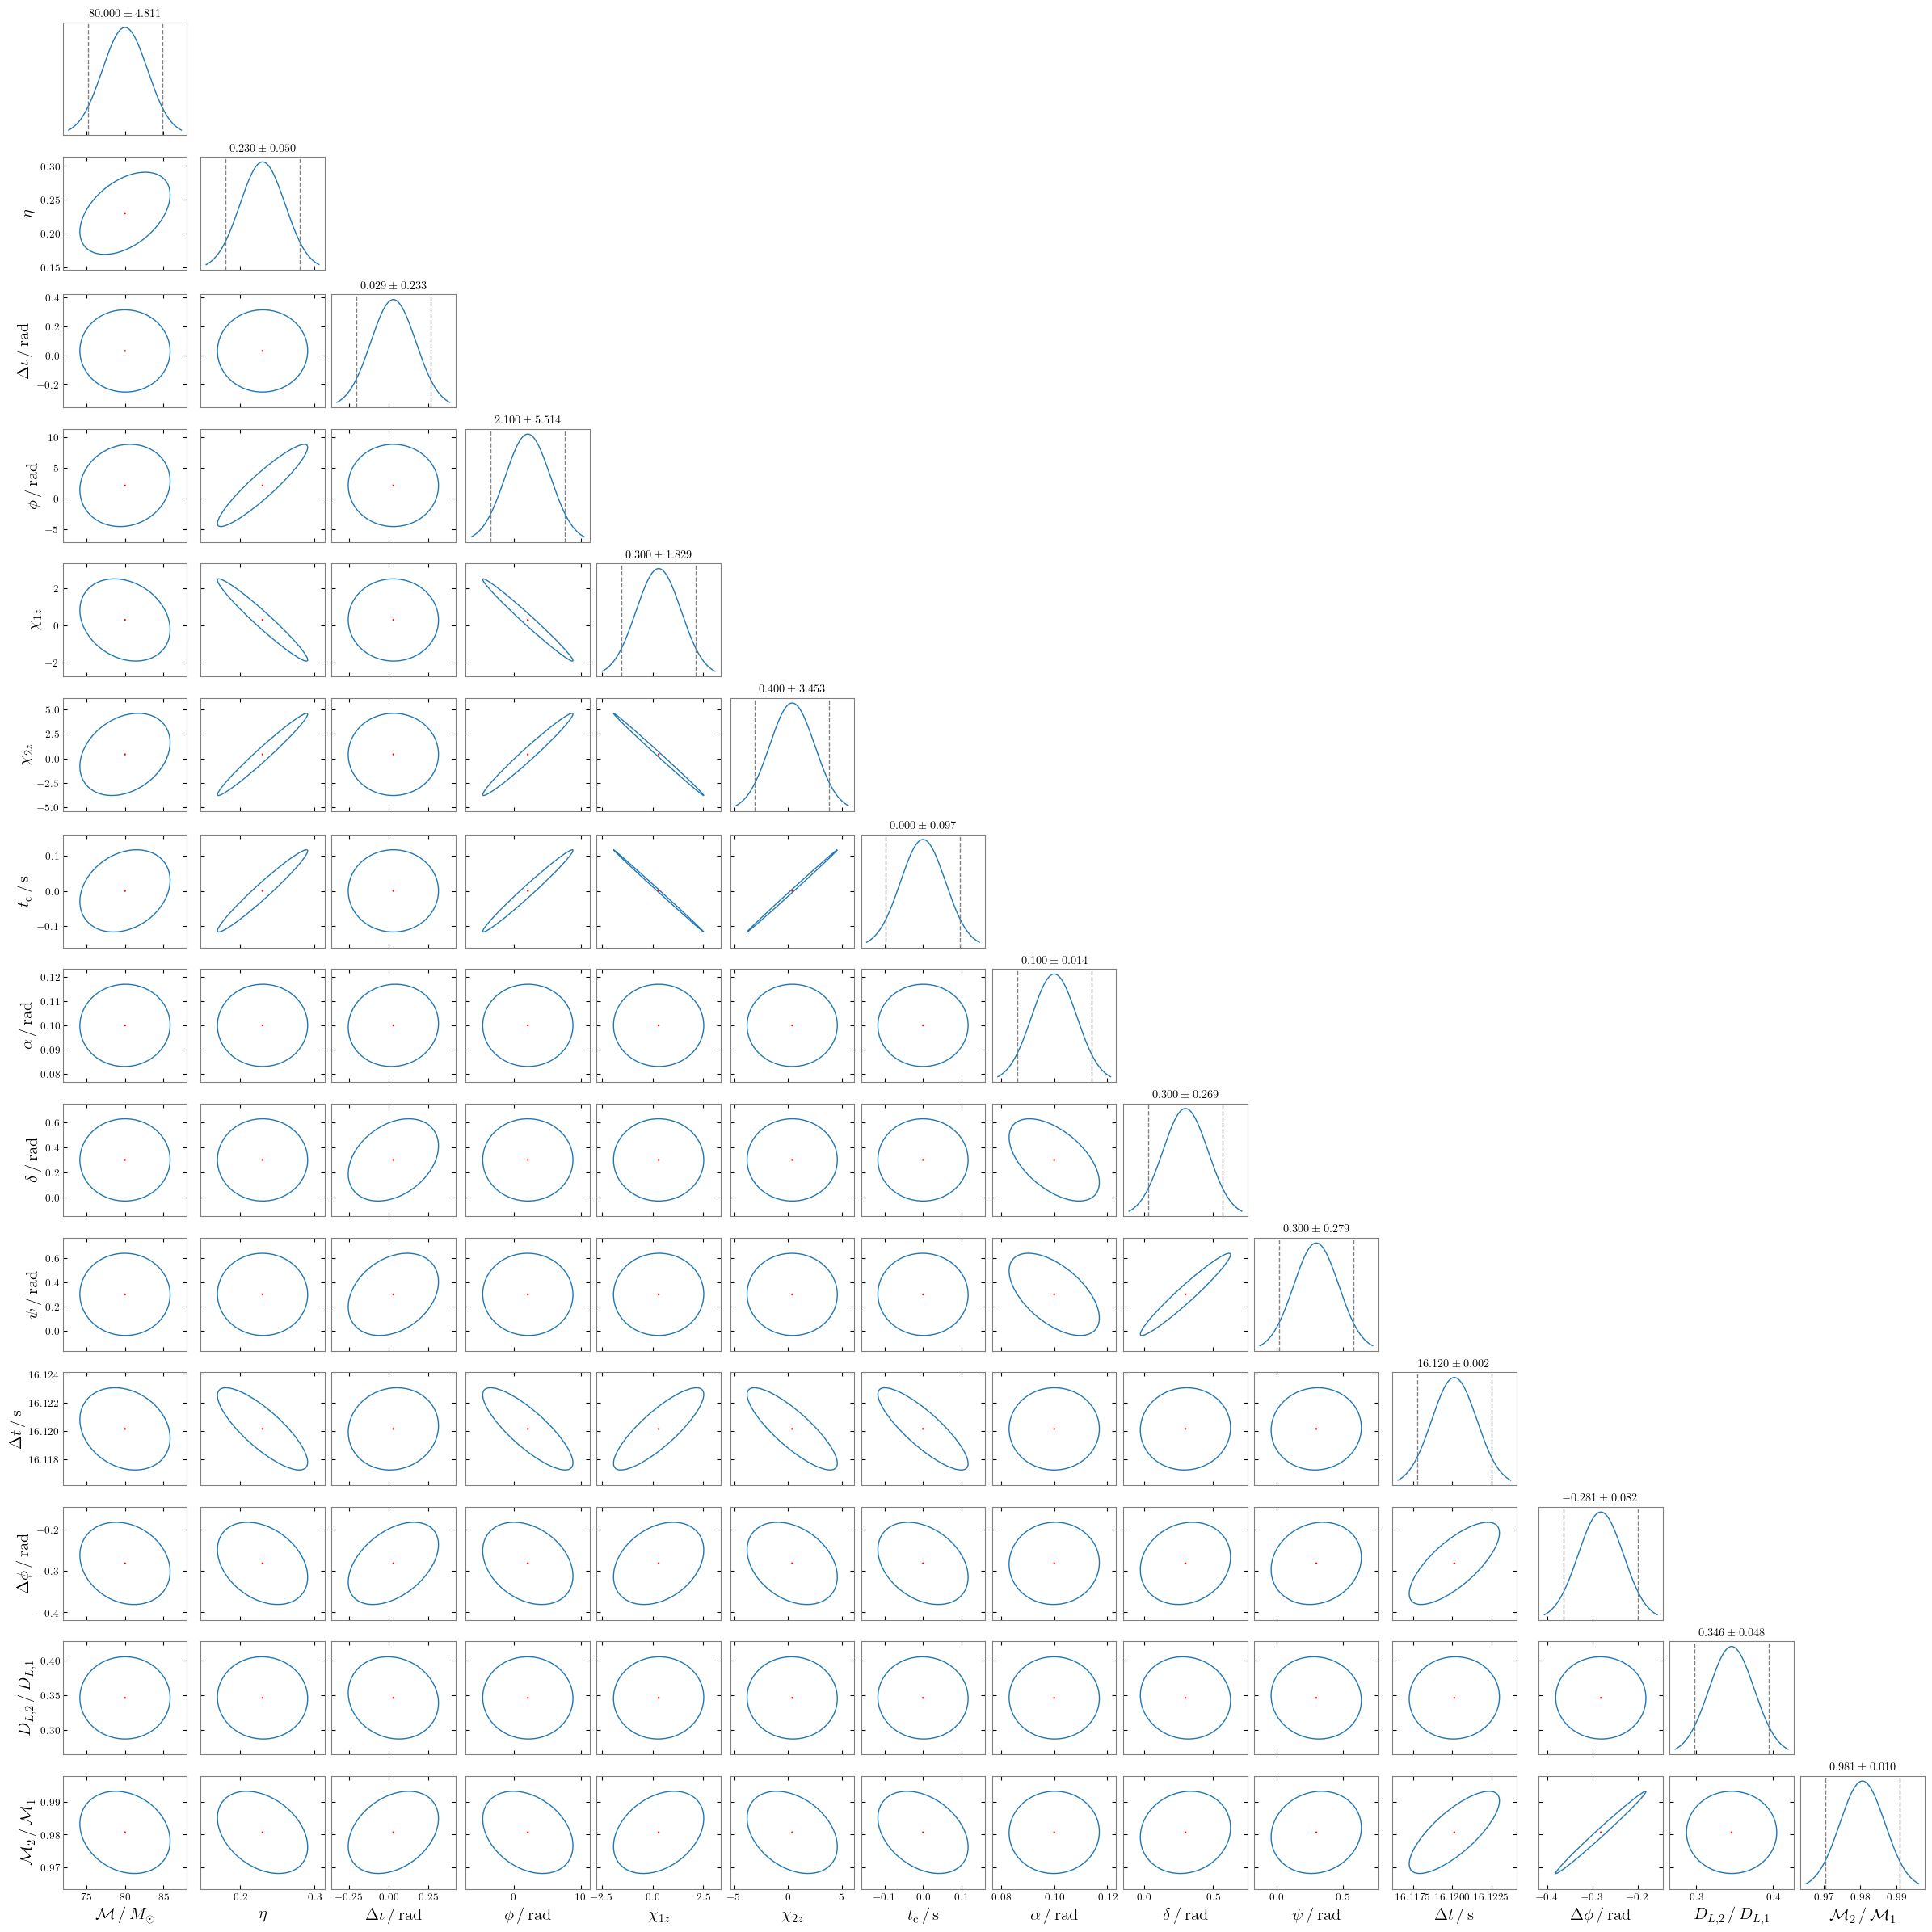

In [32]:
fig = plot_corners(
    transformed_cov_mat[:, :, idx], transformed_keys, range(14), 
    event=parameters, labels=labels, color='C0'
)

In [12]:
transformed_keys, 2 * np.sqrt(transformed_cov_mat[:, :, 1].astype(np.float64))[np.diag_indices(transformed_cov_mat.shape[0])]

(['Mc',
  'eta',
  'delta_iota',
  'phase',
  'chi1z',
  'chi2z',
  'tcoal',
  'theta',
  'phi',
  'psi',
  'delta_time',
  'delta_phi',
  'relative_distance',
  'relative_mass'],
 Array([5.84927972e+00, 6.08377694e-02, 2.83842002e-01, 6.70412719e+00,
        2.22434719e+00, 4.19868499e+00, 1.17505742e-01, 1.70007315e-02,
        3.26653971e-01, 3.39278416e-01, 2.89623179e-03, 9.94988281e-02,
        4.89482606e-01, 1.29993962e-02], dtype=float64))

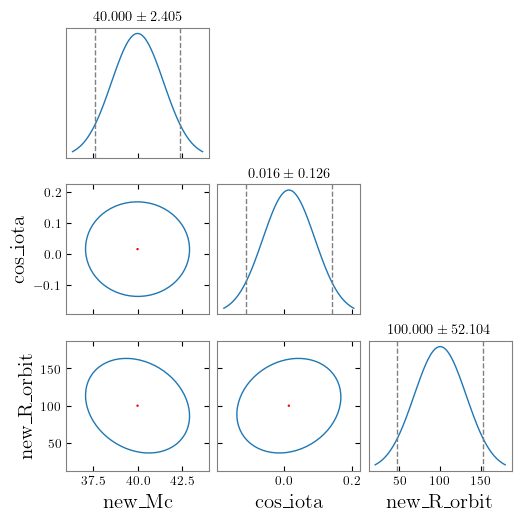

In [13]:
def simple_transform(injection_parameters):
    return {
        'cos_iota': np.cos(injection_parameters['iota']),
        # 'cos_iota': injection_parameters['iota'],
        'new_R_orbit': injection_parameters['R_orbit'],
        'new_Mc': injection_parameters['Mc'] / 2,
    }


transformed_cov_mat, transformed_parameters, transformed_keys = covariance_change_variable(
    reduced_cov_mats, lensing_parameters, simple_transform, 
    ['iota', 'R_orbit', 'Mc']
)

idx = 1
indices = np.arange(0, len(transformed_keys))
indices = np.array([0, 2, 11])
parameters = {key: val[idx] for key, val in transformed_parameters.items()}
_keys = [transformed_keys[i] for i in indices]
# parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    transformed_cov_mat[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

['mass_1', 'mass_2'] [0 1]


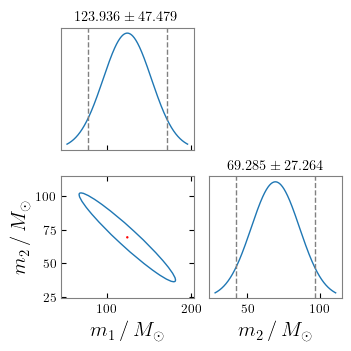

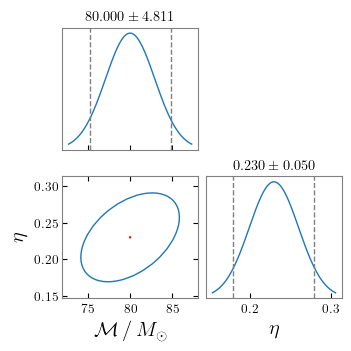

In [27]:
def simple_transform(injection_parameters):
    m1, m2 = m1m2_from_Mceta(
        injection_parameters['Mc'], injection_parameters['eta']
    )
    return {
        'mass_1': m1, 'mass_2': m2,
    }


transformed_cov_mat, transformed_parameters, transformed_keys = covariance_change_variable(
    reduced_cov_mats, lensing_parameters, 
    simple_transform, ['Mc', 'eta']
)

idx = 1
indices = np.arange(0, len(transformed_keys))
indices = np.array([0, 1])
parameters = {key: val[idx] for key, val in transformed_parameters.items()}
# parameters['delta_time'] *= DAY_TO_SEC 

_keys = [transformed_keys[i] for i in indices]
print(_keys, indices)
fig = plot_corners(
    transformed_cov_mat[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

_keys = list(lensing_parameters.keys()).copy()
_keys = [_keys[i] for i in indices]
parameters = {key: val[idx] for key, val in lensing_parameters.items()}
fig = plot_corners(
    reduced_cov_mats[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

## Check with direct Fisher matrix of component masses

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


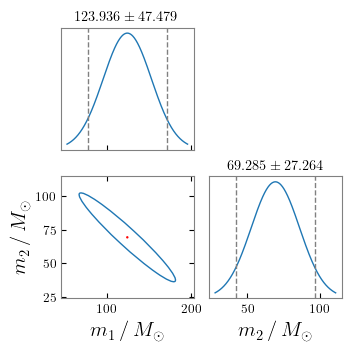

In [15]:
trans_cov_mat, ie = compute_covariance_matrix(direct_HLV_fisher)

indices = [-2, -1]
_keys = list(trans_lensing_parameters.keys()).copy()
_keys = [_keys[i] for i in indices]
parameters = {key: val[idx] for key, val in trans_lensing_parameters.items()}
fig = plot_corners(
    trans_cov_mat[:, :, idx], _keys, indices, 
    event=parameters, labels=labels, color='C0'
)

## Check with direct Fisher matrix from flexible model

In [7]:
H1_lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_lensed = network.DetNet({'H1': H1_lensed, 'L1': L1_lensed, 'V1': V1_lensed})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: [2.76161987], Maximum duration: [0.25140763].

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 2.7616198677010635, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 2.7616198677010635, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: [2.76161987], Maximum duration: [0.25140763].

Warnin

In [47]:
model_parameters = L1_AGN.convert_to_general_lensed_parameters(lensing_parameters)

lensed_HLV_fisher = HLV_lensed.FisherMatr(model_parameters, res=1000)
keys = list(model_parameters.keys()).copy()
lensed_fisher_mat, rm_keys = reduce_Fisher_matrix(lensed_HLV_fisher, keys=keys)
print(rm_keys)
lensed_cov_mats, ie = compute_covariance_matrix(lensed_fisher_mat)

Computing Fisher for H1...
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.86655731713929.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 17.65215266133077, Maximum duration: 32.94742119336045.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 30.640940863459154, Maximum duration: 33.02149006836768.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: 6.6859710754931845, Maximum duration: 32.86655731713929.

Warning! Some of the input parameters will likely yield waveforms with signal length longer th

/users/hin-wai.leong/.conda/envs/180125_py311_AGNLensing/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


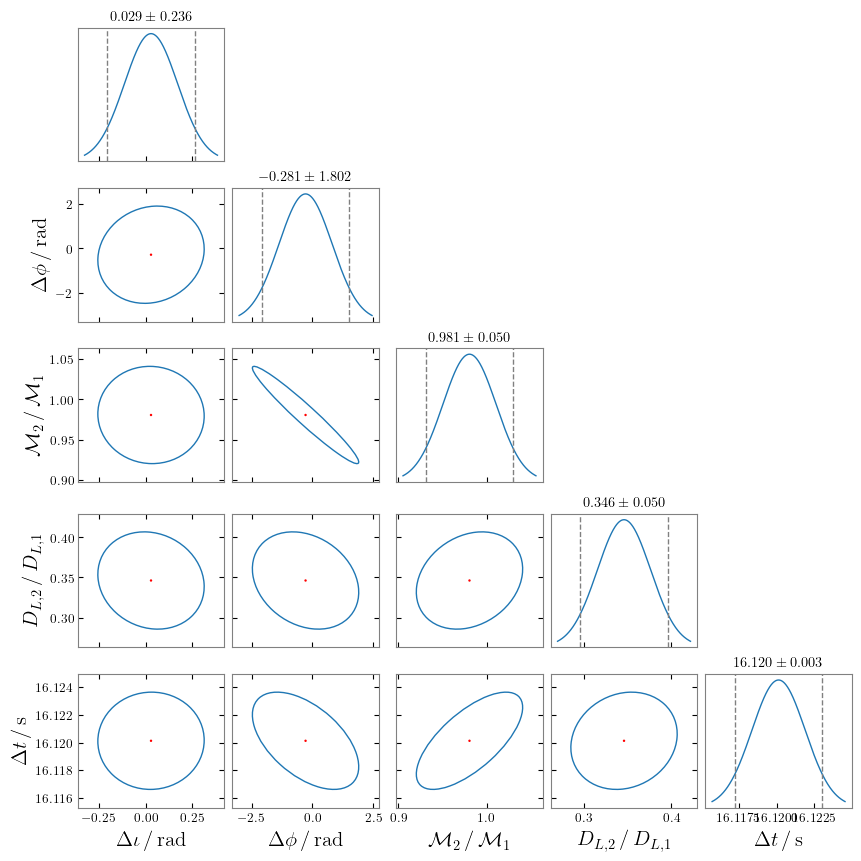

In [48]:
idx = 1
plot_keys = ['delta_iota', 'delta_phase', 'relative_mass', 'relative_distance', 'delta_time']
indices = [keys.index(key) for key in plot_keys]
# plot_keys = [model_parameters[i] for i in indices]
dt_idx = keys.index('delta_time')
# Convert delta_time from days to seconds
lensed_cov_mats[dt_idx, :, :] *= DAY_TO_SEC
lensed_cov_mats[:, dt_idx, :] *= DAY_TO_SEC
parameters = {key: model_parameters[key][idx] for key in keys}
parameters['delta_time'] *= DAY_TO_SEC 

fig = plot_corners(
    lensed_cov_mats[:, :, idx], plot_keys, indices, 
    event=parameters, labels=labels, color='C0'
)

In [41]:
len(keys), parameters, len(model_parameters), keys

(16,
 {'theta': Array(0.1, dtype=float64),
  'phi': Array(0.3, dtype=float64),
  'chi2z': Array(0.4, dtype=float64),
  'chi1z': Array(0.3, dtype=float64),
  'psi': Array(0.3, dtype=float64),
  'phase': Array(2.24067856, dtype=float64),
  'tcoal': Array(0., dtype=float64),
  'dL': Array(5.39734703, dtype=float64),
  'Mc': Array(81.43021283, dtype=float64),
  'iota': Array(1.54044511, dtype=float64),
  'eta': Array(0.23, dtype=float64),
  'delta_iota': Array(0.02928652, dtype=float64),
  'delta_phase': Array(-0.28135712, dtype=float64),
  'relative_distance': Array(0.34621048, dtype=float64),
  'relative_mass': Array(0.98068038, dtype=float64),
  'delta_time': Array(16.12013127, dtype=float64)},
 19,
 ['theta',
  'phi',
  'chi2z',
  'chi1z',
  'psi',
  'phase',
  'tcoal',
  'dL',
  'Mc',
  'iota',
  'eta',
  'delta_iota',
  'delta_phase',
  'relative_distance',
  'relative_mass',
  'delta_time'])

In [40]:
print(dict(zip(all_keys, lensed_cov_mats[:, :, idx][np.diag_indices(lensed_cov_mats.shape[0])])))

{'theta': 7.8746928718460813086e-05, 'phi': 0.12946496071270402473, 'chi2z': 4.3532551720895256153, 'chi1z': 1.216708134874894931, 'psi': 0.12429937212690135573, 'phase': 12.364066029277873682, 'M_lz': 0.0033983621099351064149, 'src_pos': 0.38253451305786234649, 'tcoal': 14.097251492265495898, 'dL': 0.03461286656582106963, 'Mc': 0.0009154148902666100259, 'iota': 0.020530853895433156392, 'eta': 1.1997851137227997231, 'R_orbit': 0.0009211515533384905235, 'delta_iota': 0.0009073940490065914889, 'delta_phase': 3.072858753669936945e-06}


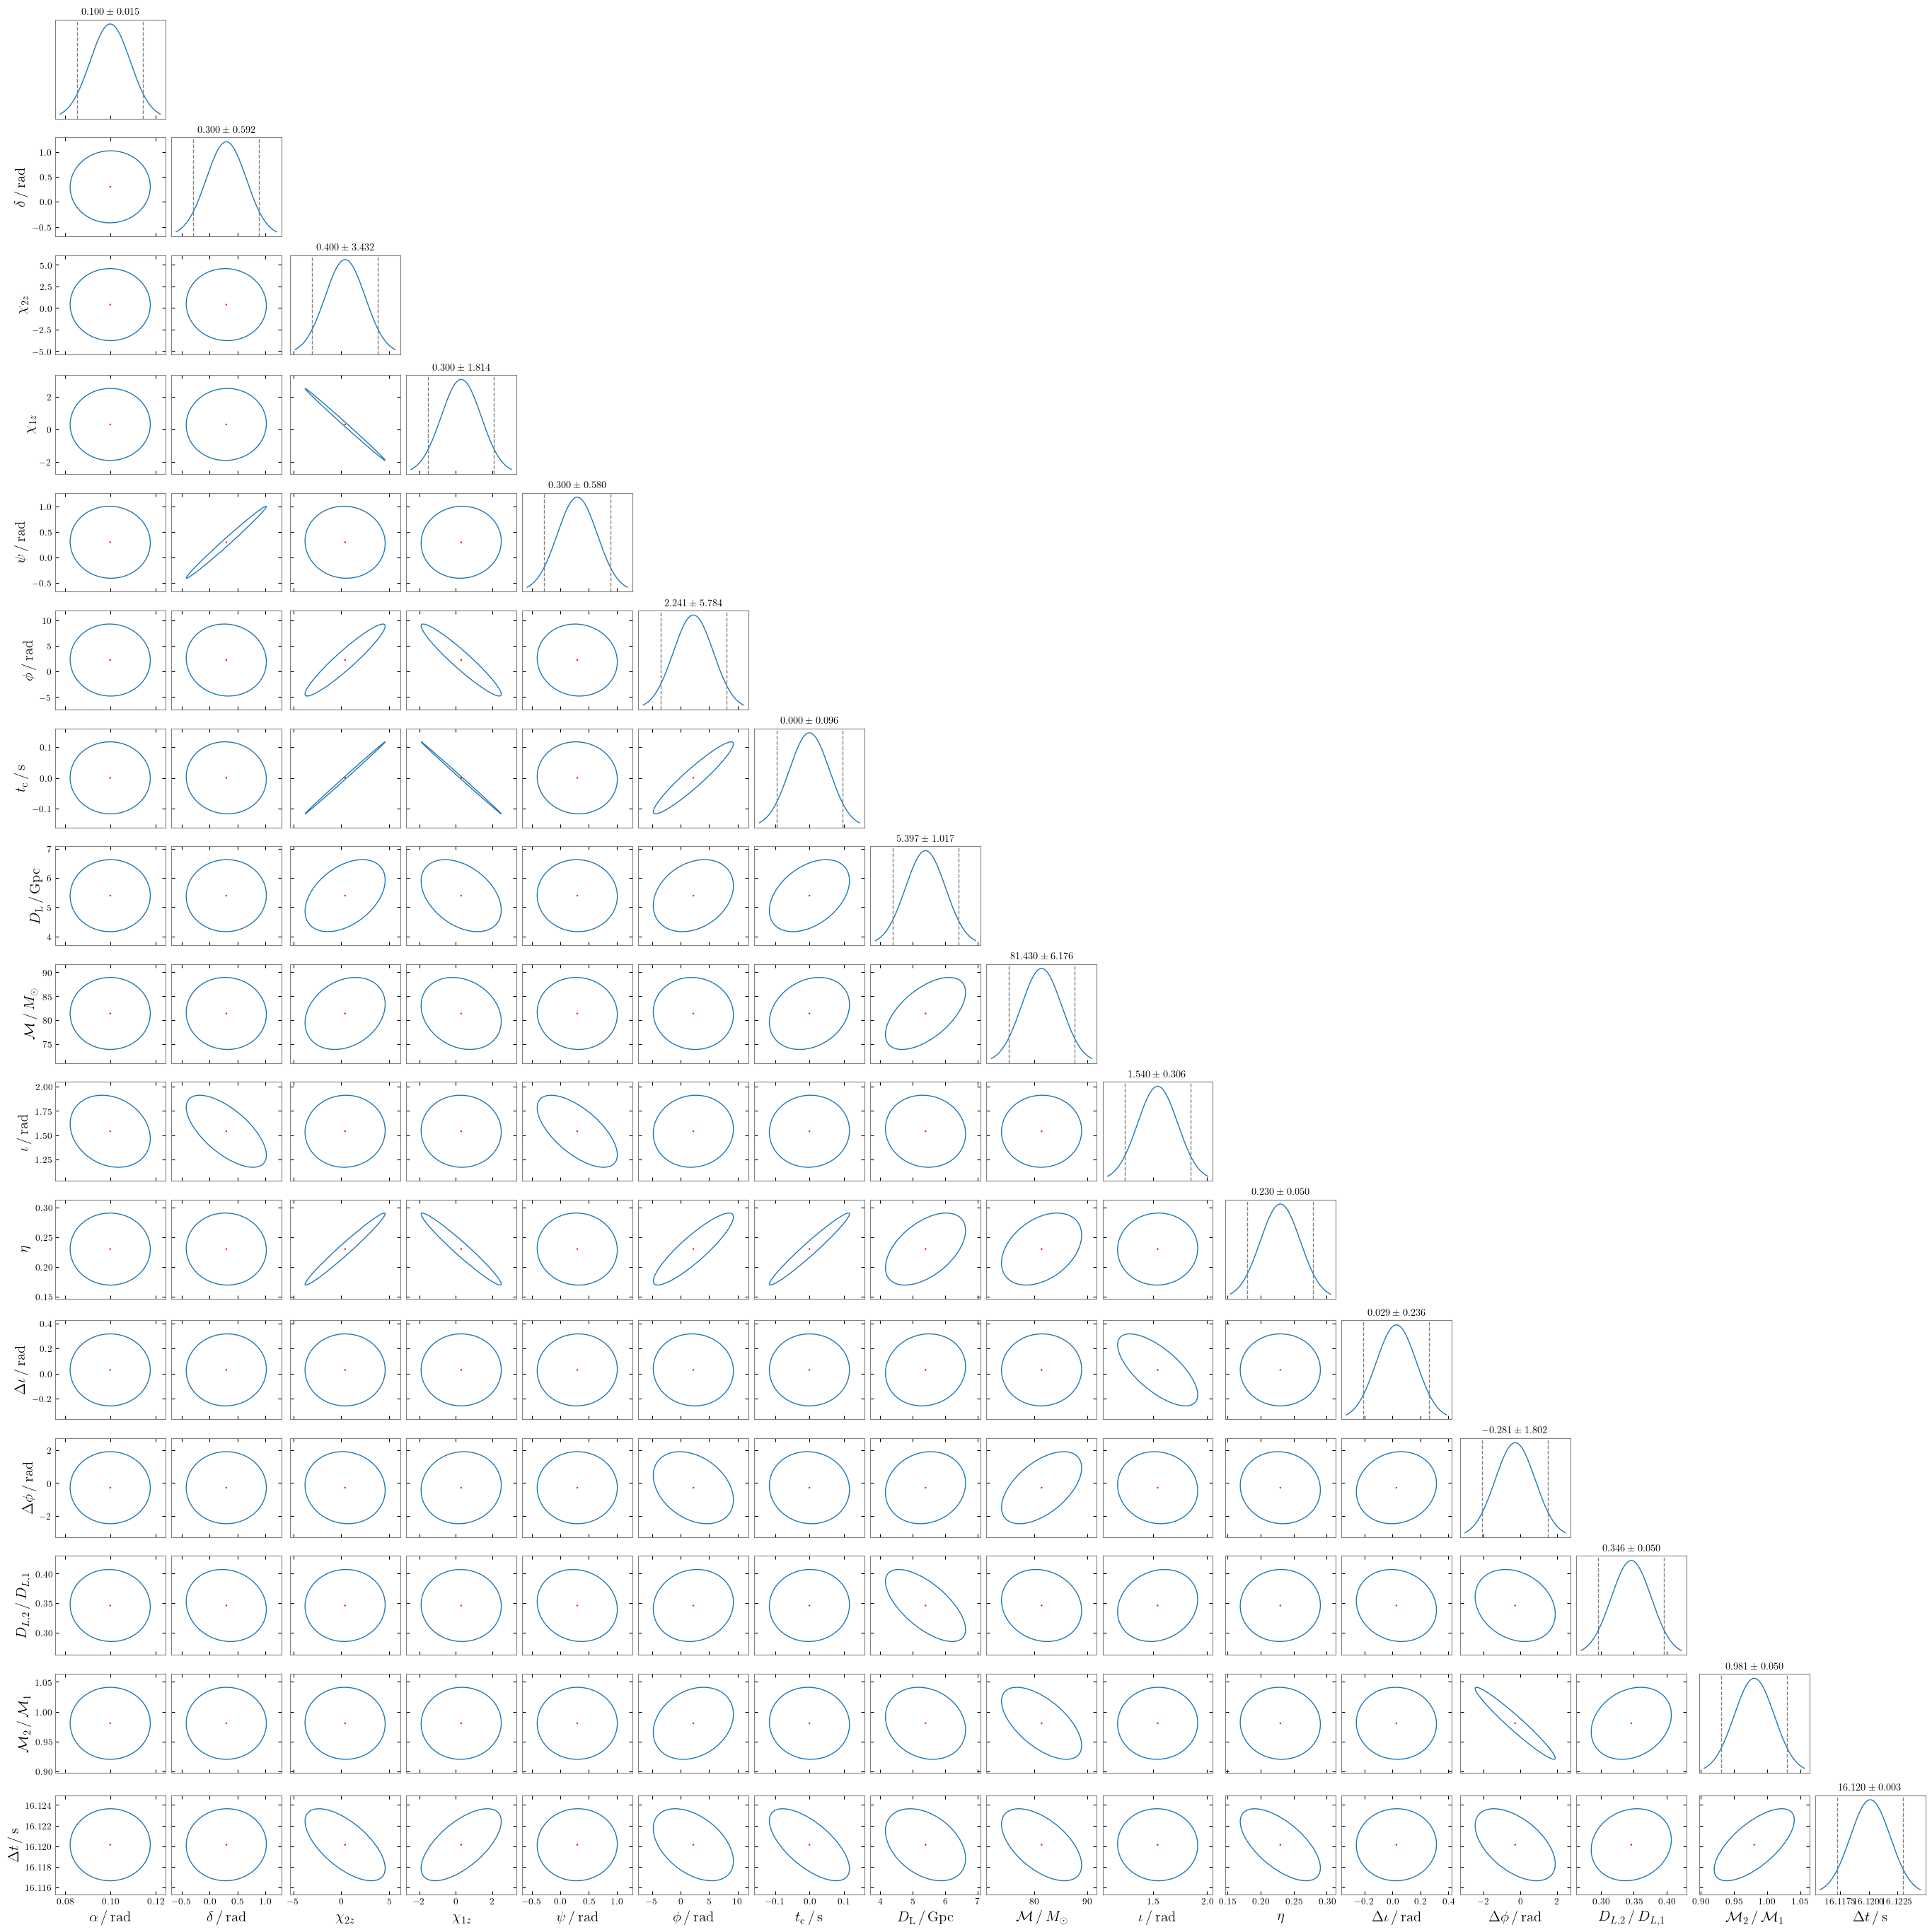

In [42]:
fig = plot_corners(
    lensed_cov_mats[:, :, idx], keys, range(16), 
    event=parameters, labels=labels, color='C0'
)

In [19]:
lensing_parameters

{'Mc': Array([80., 80., 80.], dtype=float64),
 'eta': Array([0.23, 0.23, 0.23], dtype=float64),
 'iota': Array([1.55508836, 1.55508836, 1.55508836], dtype=float64),
 'phase': Array([2.1, 2.1, 2.1], dtype=float64),
 'chi1z': Array([0.3, 0.3, 0.3], dtype=float64),
 'chi2z': Array([0.4, 0.4, 0.4], dtype=float64),
 'tcoal': Array([0., 0., 0.], dtype=float64),
 'theta': Array([0.1, 0.1, 0.1], dtype=float64),
 'phi': Array([0.3, 0.3, 0.3], dtype=float64),
 'psi': Array([0.3, 0.3, 0.3], dtype=float64),
 'dL': Array([2., 2., 2.], dtype=float64),
 'R_orbit': Array([100., 100., 100.], dtype=float64),
 'M_lz': Array([500000., 500000., 500000.], dtype=float64),
 'src_pos': Array([-0.05, -0.15, -0.25], dtype=float64)}

In [20]:
mat = onp.identity(5)
mat[onp.ix_([1, 4], [1, 4])] = 10
mat

array([[ 1.,  0.,  0.,  0.,  0.],
       [ 0., 10.,  0.,  0., 10.],
       [ 0.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  0.],
       [ 0., 10.,  0.,  0., 10.]])

In [21]:
sub_array = onp.arange(1, 5).reshape(2, 2)
sub_array = sub_array[:, :, None] * np.arange(1, 4)

In [22]:
mat = onp.zeros((5, 5, 3))
diag_idx = np.diag_indices(5)
mat[diag_idx] = 1
mat[onp.ix_([1, 4], [1, 4])] = sub_array
mat[:, :, 1]

array([[1., 0., 0., 0., 0.],
       [0., 2., 0., 0., 4.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 6., 0., 0., 8.]])

In [25]:
def test_transform(parameters):
    return {
        'double_mass': parameters['mass'] * 2,
        'cos_iota': np.cos(parameters['iota'])
    }

jax.jacfwd(test_transform)({
    'mass': 10.0, 'iota': np.pi / 2
})

{'cos_iota': {'iota': Array(-1., dtype=float64, weak_type=True),
  'mass': Array(-0., dtype=float64, weak_type=True)},
 'double_mass': {'iota': Array(0., dtype=float64, weak_type=True),
  'mass': Array(2., dtype=float64, weak_type=True)}}